# Huang et al. (2025) 再現（学習機構を選択可能）

このノートブックは論文 **"Transformers Learn to Implement Multi-step Gradient Descent with Chain of Thought"** の設定を使って、
学習機構を切り替えて比較できます。

- タスク: in-context weight prediction（線形回帰）
- モデル: one-layer linear self-attention（残差あり）
- 実験設定: `d=10, n=20, eta=0.4, batch_size=1000, adam_lr=1e-3, iterations=500`
- 学習モード `TRAINING_MODE`:
  - `"no_cot"`: 訓練時は CoT なし（`Z0` の1回読み出しで `w*` 回帰）
  - `"cot_split"`: k-step CoT 訓練（`k_train` 固定）+ 評価時 `k_eval` 掃引
  - `"cot_tied"`: k-step CoT 訓練と評価を同じ `k` で実行（train/eval 非分離）
- `w0` 初期化は `W0_INIT_MODE = "zero" | "random" | "gd1"` で切替可能（`gd1` は 0 からの1-step GD 推定）

In [13]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ===== 実験設定 =====
D = 10
N = 80
ETA_GD = 0.4
BATCH_SIZE = 1000
ADAM_LR = 1e-3
PARAM_L2_LAMBDA = 0.1 # パラメータ正則化係数（0.0 で無効）
ITERATIONS = 4000  # 固定 iteration
EVAL_K_LIST = [0, 2, 4, 6, 8, 10]
W0_INIT_MODE = "random"  # "zero" | "random" | "gd1"
W0_GD_ETA = ETA_GD      # gd1 モード時の学習率

TRAINING_MODE = "no_cot"   # "no_cot" | "cot_split" | "cot_tied"
COT_TRAIN_K = 1             # TRAINING_MODE="cot_split" のときに使用
COT_TIED_K_LIST = EVAL_K_LIST  # TRAINING_MODE="cot_tied" のときに使用
HEATMAP_K = COT_TIED_K_LIST[-1]  # cot_tied 時に可視化する k

SEED = 420

# 実行時間が長い場合だけここを True に変更
QUICK_MODE = False
if QUICK_MODE:
    BATCH_SIZE = 256
    ITERATIONS = 200

DE = 2 * D + 2

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={device}, d={D}, n={N}, B={BATCH_SIZE}, iters={ITERATIONS}, w0={W0_INIT_MODE}, mode={TRAINING_MODE}, l2={PARAM_L2_LAMBDA}")

device=cpu, d=10, n=80, B=1000, iters=4000, w0=random, mode=no_cot, l2=0.1


In [14]:
def sample_batch(batch_size, d=D, n=N, device=device):
    """
    X: [B, d, n], w_star: [B, d], y: [B, n]
    x_i, w* ~ N(0, I), y_i = <w*, x_i>
    """
    X = torch.randn(batch_size, d, n, device=device)
    w_star = torch.randn(batch_size, d, device=device)
    y = torch.einsum("bd,bdn->bn", w_star, X)
    return X, y, w_star


def sample_w0(X, y, d=D, n=N, device=device):
    """初期条件 w0 を設定値に応じて生成する。"""
    batch_size = X.shape[0]
    if W0_INIT_MODE == "zero":
        return torch.zeros(batch_size, d, device=device)
    if W0_INIT_MODE == "random":
        return torch.randn(batch_size, d, device=device)
    if W0_INIT_MODE == "gd1":
        # 線形回帰損失で w=0 からの1-step GD: w1 = (eta/n) Xy
        return (W0_GD_ETA / n) * torch.einsum("bdn,bn->bd", X, y)
    raise ValueError(f"Unknown W0_INIT_MODE: {W0_INIT_MODE}")


def gt_weights(X, y, w_star, k, eta=ETA_GD):
    """
    w_0=0 から始める ground-truth GD の軌跡 [w_0, ..., w_k, w_{k+1}=w*] を返す
    """
    B, d, n = X.shape
    w_list = [torch.zeros(B, d, device=X.device)]
    for _ in range(k):
        w_prev = w_list[-1]
        resid = torch.einsum("bdn,bd->bn", X, w_prev) - y
        grad = torch.einsum("bdn,bn->bd", X, resid) / n
        w_next = w_prev - eta * grad
        w_list.append(w_next)
    w_list.append(w_star)
    return w_list


def build_Z(X, y, w_prefix):
    """
    Z_i を構築。
    w_prefix は [w_0, ..., w_i] のリスト。
    戻り値: Z [B, de, n+i+1]
    """
    B, d, n = X.shape
    i = len(w_prefix) - 1
    L = n + i + 1

    Z = torch.zeros(B, DE, L, device=X.device)
    Z[:, :d, :n] = X
    Z[:, d, :n] = y

    for t, w_t in enumerate(w_prefix):
        col = n + t
        Z[:, d + 1 : d + 1 + d, col] = w_t

    Z[:, -1, :] = 1.0
    return Z


def f_lsa_last(Z, V, W, n=N):
    """
    f_LSA(Z;V,W)[:, -1] = Z[:, -1] + V Z (Z^T W Z[:, -1]) / n
    Z: [B, de, L], V/W: [de, de]
    return: [B, de]
    """
    z_last = Z[:, :, -1]
    Wz = torch.einsum("ij,bj->bi", W, z_last)
    scores = torch.einsum("bjl,bj->bl", Z, Wz) / n
    weighted = torch.einsum("bjl,bl->bj", Z, scores)
    out_last = z_last + torch.einsum("ij,bj->bi", V, weighted)
    return out_last


def cot_loss(V, W, X, y, w_star, k):
    """
    Eq.(5) 相当: 1/2 * sum_{i=0..k} || f(Z_i)[:,-1] - (0,0,w_{i+1},1) ||^2
    """
    w_list = gt_weights(X, y, w_star, k)
    total = 0.0

    for i in range(k + 1):
        Z_i = build_Z(X, y, w_list[: i + 1])
        pred = f_lsa_last(Z_i, V, W)

        target = torch.zeros_like(pred)
        target[:, D + 1 : D + 1 + D] = w_list[i + 1]
        target[:, -1] = 1.0

        total = total + 0.5 * ((pred - target) ** 2).sum(dim=1).mean()

    return total


def no_cot_train_loss(V, W, X, y, w_star):
    """
    no-CoT 訓練: 設定した w0 の Z0 から1回読み出し、真値 (0,0,w*,1) との誤差のみを最小化
    """
    B = X.shape[0]
    w0 = sample_w0(X, y, D, N, X.device)
    Z0 = build_Z(X, y, [w0])
    pred = f_lsa_last(Z0, V, W)

    target = torch.zeros_like(pred)
    target[:, D + 1 : D + 1 + D] = w_star
    target[:, -1] = 1.0

    loss = 0.5 * ((pred - target) ** 2).sum(dim=1).mean()
    return loss


def eval_loss(V, W, k_eval, batch_size=2048):
    """
    Eq.(7) 相当: 推論時に autoregressive で k_eval ステップ生成して最終誤差を測る
    """
    X, y, w_star = sample_batch(batch_size)

    with torch.no_grad():
        w0 = sample_w0(X, y, D, N, device)
        w_prefix = [w0]
        for _ in range(k_eval):
            Z = build_Z(X, y, w_prefix)
            pred = f_lsa_last(Z, V, W)
            w_hat = pred[:, D + 1 : D + 1 + D]
            w_prefix.append(w_hat)

        Z_final = build_Z(X, y, w_prefix)
        pred_final = f_lsa_last(Z_final, V, W)

        target = torch.zeros_like(pred_final)
        target[:, D + 1 : D + 1 + D] = w_star
        target[:, -1] = 1.0

        loss = 0.5 * ((pred_final - target) ** 2).sum(dim=1).mean().item()

    return loss


def parameter_l2_penalty(V, W):
    """V, W に対する L2 正則化項（係数は外側で掛ける）。"""
    return V.pow(2).sum() + W.pow(2).sum()

In [ ]:
def train_model_no_cot(iterations=ITERATIONS, log_every=1):
    """
    no-CoT 学習（訓練時は Z0 の1ステップ読み出しのみ）。
    返り値: (V, W, eval_curve)
    """
    V = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    W = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    opt = torch.optim.Adam([V, W], lr=ADAM_LR)

    eval_curve = []
    for t in range(iterations):
        X, y, w_star = sample_batch(BATCH_SIZE)
        data_loss = no_cot_train_loss(V, W, X, y, w_star)
        reg_loss = PARAM_L2_LAMBDA * parameter_l2_penalty(V, W)
        loss = data_loss + reg_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if t % log_every == 0:
            ev = eval_loss(V, W, k_eval=0)
            eval_curve.append(ev)

    return V.detach(), W.detach(), np.array(eval_curve)


def train_model_cot(k_train, iterations=ITERATIONS, log_every=1):
    """
    k-step CoT 学習。
    返り値: (V, W, eval_curve)
    """
    V = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    W = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    opt = torch.optim.Adam([V, W], lr=ADAM_LR)

    eval_curve = []
    for t in range(iterations):
        X, y, w_star = sample_batch(BATCH_SIZE)
        data_loss = cot_loss(V, W, X, y, w_star, k=k_train)
        reg_loss = PARAM_L2_LAMBDA * parameter_l2_penalty(V, W)
        loss = data_loss + reg_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if t % log_every == 0:
            ev = eval_loss(V, W, k_eval=k_train)
            eval_curve.append(ev)

    return V.detach(), W.detach(), np.array(eval_curve)

In [16]:
# 学習を実行（TRAINING_MODE で切替）
final_eval = {}
V_vis, W_vis = None, None
heatmap_label = ""

if TRAINING_MODE == "no_cot":
    print("training with no-CoT objective ...")
    V_tr, W_tr, train_curve = train_model_no_cot(iterations=ITERATIONS)
    for k_eval in EVAL_K_LIST:
        final_eval[k_eval] = eval_loss(V_tr, W_tr, k_eval=k_eval)
    result_label = f"no-CoT train, varying k_eval (w0={W0_INIT_MODE})"
    V_vis, W_vis = V_tr, W_tr
    heatmap_label = "no_cot"

elif TRAINING_MODE == "cot_split":
    print(f"training with CoT (fixed k_train={COT_TRAIN_K}) ...")
    V_tr, W_tr, train_curve = train_model_cot(k_train=COT_TRAIN_K, iterations=ITERATIONS)
    for k_eval in EVAL_K_LIST:
        final_eval[k_eval] = eval_loss(V_tr, W_tr, k_eval=k_eval)
    result_label = f"CoT split: k_train={COT_TRAIN_K}, varying k_eval"
    V_vis, W_vis = V_tr, W_tr
    heatmap_label = f"cot_split(k_train={COT_TRAIN_K})"

elif TRAINING_MODE == "cot_tied":
    print(f"training with tied CoT over k={COT_TIED_K_LIST} ...")
    train_curve = None
    model_by_k = {}
    for k in COT_TIED_K_LIST:
        V_k, W_k, curve_k = train_model_cot(k_train=k, iterations=ITERATIONS)
        final_eval[k] = eval_loss(V_k, W_k, k_eval=k)
        model_by_k[k] = (V_k, W_k)
    result_label = "CoT tied: train/eval with same k"

    if HEATMAP_K not in model_by_k:
        raise ValueError(f"HEATMAP_K={HEATMAP_K} is not in COT_TIED_K_LIST={COT_TIED_K_LIST}")
    V_vis, W_vis = model_by_k[HEATMAP_K]
    heatmap_label = f"cot_tied(k={HEATMAP_K})"

else:
    raise ValueError(f"Unknown TRAINING_MODE: {TRAINING_MODE}")

print("done")
print(f"final eval loss ({result_label}):")
for k_eval in sorted(final_eval.keys()):
    print(f"k_eval={k_eval:>2}: {final_eval[k_eval]:.6f}")

training with no-CoT objective ...
done
final eval loss (no-CoT train, varying k_eval (w0=random)):
k_eval= 0: 1.368748
k_eval= 2: 0.207605
k_eval= 4: 0.173651
k_eval= 6: 0.191190
k_eval= 8: 0.197425
k_eval=10: 0.203117


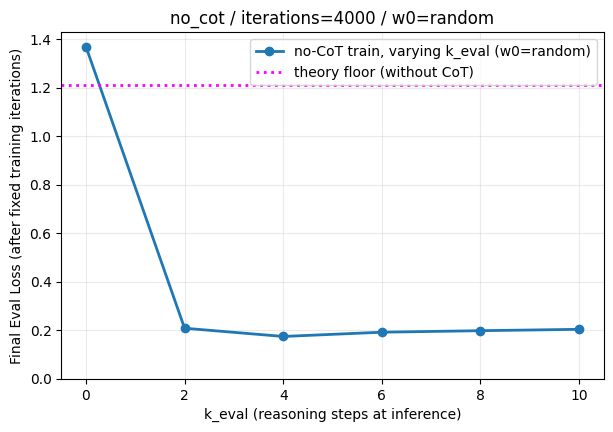

theoretical without-CoT floor: 1.2088


In [ ]:
# iteration=ITERATIONS 固定で、横軸 k_eval の可視化
ks = np.array(sorted(final_eval.keys()))
vals = np.array([final_eval[k] for k in ks])

plt.figure(figsize=(7, 4.5))
plt.plot(ks, vals, marker="o", linewidth=2, label=result_label)

plt.xlabel("k_eval (reasoning steps at inference)")
plt.ylabel("Final Eval Loss (after fixed training iterations)")
plt.title(f"{TRAINING_MODE} / iterations={ITERATIONS} / w0={W0_INIT_MODE}")
plt.xticks(ks)
plt.ylim(bottom=0)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

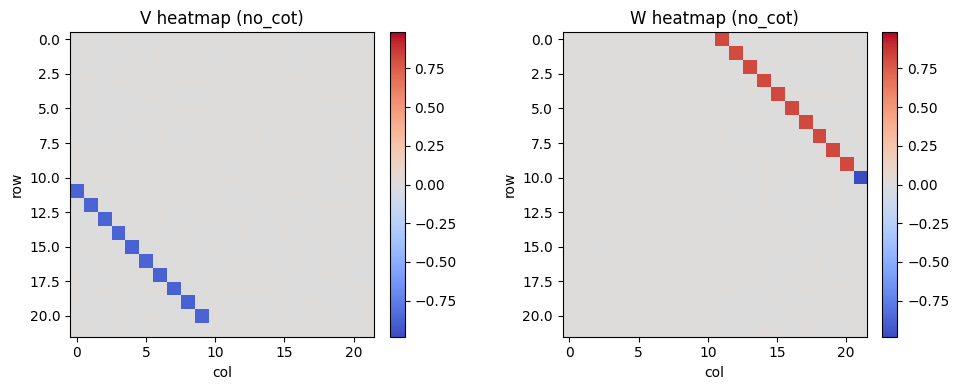

visualized model: no_cot
V shape=(22, 22), W shape=(22, 22)


In [18]:
# 学習後パラメータの可視化（特定 k のモデル）
if V_vis is None or W_vis is None:
    raise ValueError("V_vis/W_vis is None. 先に学習セルを実行してください。")

V_np = V_vis.detach().cpu().numpy()
W_np = W_vis.detach().cpu().numpy()

vmax = float(max(np.abs(V_np).max(), np.abs(W_np).max()))
vmax = max(vmax, 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(V_np, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[0].set_title(f"V heatmap ({heatmap_label})")
axes[0].set_xlabel("col")
axes[0].set_ylabel("row")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(W_np, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[1].set_title(f"W heatmap ({heatmap_label})")
axes[1].set_xlabel("col")
axes[1].set_ylabel("row")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"visualized model: {heatmap_label}")
print(f"V shape={V_np.shape}, W shape={W_np.shape}")